<a href="https://colab.research.google.com/github/MTijbout/ACME-Pulse/blob/master/M1U7A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis of Product Reviews
## Introduction to Artificial Intelligence — Coursework Part A

This notebook implements a full AI pipeline for multilingual sentiment analysis of customer product reviews.
Reviews are classified as **Positive**, **Neutral**, or **Negative** based on star ratings.

The pipeline covers:
1. Data loading and quality audit
2. Pre-processing and label engineering
3. Class imbalance experiments (no augmentation, data augmentation, synthetic data generation)
4. Feature extraction
5. Model training and evaluation across 6 experimental conditions (2 language scopes × 3 imbalance strategies), using Logistic Regression and an MLP Neural Network
6. Comparative analysis and evidence-based decision


\# 0b.1

## Section 0b: Configuration

This cell configures all file paths used throughout the notebook.
Run this cell first before any other section.

**Two options are available:**
- **Upload:** Upload source parquet files manually. Outputs are saved to Google Drive.
- **Google Drive:** Source files and outputs are both read from and saved to a specified
  Google Drive folder.

All paths are set once here and used automatically throughout the notebook.
No other cell contains hardcoded file paths.

In [49]:
# 0b.2

# ── [0b.2] Configuration — File Paths ────────────────────────────────────────
# Run this cell first. Sets SOURCE_PATH and OUTPUT_PATH used throughout notebook.
# Supports nested subfolders — enter paths relative to MyDrive root.
# Example: 'Coursework/AI/data' or just press Enter for MyDrive root.

import os
from google.colab import drive, files as colab_files

MYDRIVE    = '/content/drive/MyDrive'
TRAIN_FILE = 'train-product-review.parquet'
TEST_FILE  = 'test-product-review.parquet'

def list_path_contents(path, show_files=False):
    """List contents of a Drive path, showing folders and optionally files."""
    try:
        items = sorted(os.listdir(path))
        folders = [i for i in items if os.path.isdir(os.path.join(path, i))]
        files   = [i for i in items if os.path.isfile(os.path.join(path, i))]

        if folders:
            print("  📁 Folders:")
            for f in folders:
                print(f"     {f}")
        else:
            print("  (no subfolders)")

        if show_files and files:
            print("  📄 Files:")
            for f in files[:20]:  # limit to 20 files to avoid flooding output
                print(f"     {f}")
            if len(files) > 20:
                print(f"     ... and {len(files) - 20} more files")
    except Exception as e:
        print(f"  Could not list contents: {e}")

def resolve_drive_path(prompt_label, require_files=None):
    """
    Interactively resolve a Google Drive path with subfolder support.
    require_files: list of filenames that must exist at the resolved path.
    Returns the resolved absolute path string, or None if invalid.
    """
    print(f"\nContents of MyDrive root:")
    list_path_contents(MYDRIVE, show_files=(require_files is not None))

    print(f"\nEnter a folder path relative to MyDrive.")
    print(f"Examples:")
    print(f"  Coursework/AI/data    → MyDrive/Coursework/AI/data")
    print(f"  Semester1             → MyDrive/Semester1")
    print(f"  (press Enter)         → MyDrive root")

    user_input = input(f"\n{prompt_label}: ").strip().strip('/')

    if user_input == '':
        resolved = MYDRIVE
    else:
        resolved = os.path.join(MYDRIVE, user_input)

    if not os.path.exists(resolved):
        print(f"\n⚠ Path not found: {resolved}")
        print("Please re-run this cell with a valid path.")
        return None

    print(f"\nContents of selected path ({resolved}):")
    list_path_contents(resolved, show_files=True)

    if require_files:
        missing = [f for f in require_files
                   if not os.path.exists(os.path.join(resolved, f))]
        if missing:
            print(f"\n⚠ Required files not found in this location:")
            for f in missing:
                print(f"  - {f}")
            print("Please re-run this cell and choose a folder containing these files.")
            return None

    return resolved + '/'

# ── Step 1: Always mount Google Drive ────────────────────────────────────────
print("Mounting Google Drive...")
drive.mount('/content/drive', force_remount=False)
print("✓ Google Drive mounted.\n")

# ── Step 2: Choose source file location ──────────────────────────────────────
print("=" * 60)
print("SOURCE FILE CONFIGURATION")
print("=" * 60)
print("\nHow would you like to provide the source data files?")
print("  U — Upload parquet files manually")
print("  G — Load from a Google Drive folder (supports subfolders)")
source_choice = input("\nEnter U or G: ").strip().upper()

SOURCE_PATH = None

if source_choice == 'U':
    print("\nPlease upload both parquet files when prompted.")
    print("Select train-product-review.parquet AND test-product-review.parquet")
    uploaded = colab_files.upload()

    missing = [f for f in [TRAIN_FILE, TEST_FILE] if f not in uploaded]
    if missing:
        print(f"\n⚠ Warning: The following files were not uploaded: {missing}")
        print("Please re-run this cell and upload both files.")
    else:
        SOURCE_PATH = '/content/'
        print(f"\n✓ Both files uploaded successfully.")
        print(f"  Source path: {SOURCE_PATH}")

else:
    SOURCE_PATH = resolve_drive_path(
        prompt_label="Source folder path (relative to MyDrive)",
        require_files=[TRAIN_FILE, TEST_FILE]
    )
    if SOURCE_PATH:
        print(f"\n✓ Source path confirmed: {SOURCE_PATH}")

# ── Step 3: Configure output path ────────────────────────────────────────────
print("\n" + "=" * 60)
print("OUTPUT FOLDER CONFIGURATION")
print("=" * 60)
print("Where should output files (results, charts, models) be saved?")
print("This must be a Google Drive location.")
print("If the folder does not exist, it will be created automatically.")

output_input = input("\nOutput folder path (relative to MyDrive, or Enter for root): ").strip().strip('/')

if output_input == '':
    OUTPUT_PATH = MYDRIVE + '/'
else:
    OUTPUT_PATH = os.path.join(MYDRIVE, output_input) + '/'
    os.makedirs(OUTPUT_PATH, exist_ok=True)
    print(f"✓ Output folder created/confirmed: {OUTPUT_PATH}")

# ── Step 4: Summary and validation ───────────────────────────────────────────
print("\n" + "=" * 60)
print("CONFIGURATION SUMMARY")
print("=" * 60)

if SOURCE_PATH is None:
    print("⚠ Configuration incomplete — SOURCE_PATH could not be set.")
    print("  Please re-run this cell.")
else:
    print(f"  Source path:  {SOURCE_PATH}")
    print(f"  Output path:  {OUTPUT_PATH}")
    print(f"  Train file:   {SOURCE_PATH}{TRAIN_FILE}")
    print(f"  Test file:    {SOURCE_PATH}{TEST_FILE}")

    # Final file existence check
    train_ok = os.path.exists(SOURCE_PATH + TRAIN_FILE)
    test_ok  = os.path.exists(SOURCE_PATH + TEST_FILE)

    if source_choice != 'U':
        print(f"\n  Train file found: {'✓' if train_ok else '⚠ NOT FOUND'}")
        print(f"  Test file found:  {'✓' if test_ok else '⚠ NOT FOUND'}")

    if (source_choice == 'U') or (train_ok and test_ok):
        print(f"\n✓ Configuration complete. Proceed to Section 1.")
    else:
        print(f"\n⚠ Configuration incomplete. Re-run this cell.")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted.

SOURCE FILE CONFIGURATION

How would you like to provide the source data files?
  U — Upload parquet files manually
  G — Load from a Google Drive folder (supports subfolders)

Enter U or G: G

Contents of MyDrive root:
  📁 Folders:
     AI LLMs and More
     Algemene Data (G-Local)
     Breslauer Ring 14
     CV en Sollicitaties
     Colab Notebooks
     Customer
     Diplomas en Certificaten
     Enablement
     Meet Recordings
     Saved from Chrome
     ZZP.de
     _.config
     marco@crosscloud.guru
  📄 Files:
     01 RAD.gdoc
     AUAU spreadsheet.gsheet
     Activity Report - Tijbout, Marco 2.xls
     Activity Report - Tijbout, Marco.xlsx
     Ansible - Prompts.gdoc
     Architectural Vision for Agentic AI Transformation.gdoc
     Bewerbungs Tracker.gsheet
     Boeken Lijst.gsheet
     Boodschappenlijst

In [50]:
# ── Section 1: Setup & Imports ──────────────────────────────────────────────
# Install any libraries not already available in Colab

!pip install pyarrow --quiet

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# NLP & feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import string

# Machine learning - Model 1
from sklearn.linear_model import LogisticRegression

# Machine learning - Model 2
from sklearn.neural_network import MLPClassifier

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)

# Label encoding
from sklearn.preprocessing import LabelEncoder

print("All libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")

All libraries imported successfully.
Pandas version: 2.2.2


/# 2.1

## Section 2: Load Data

This section loads the training and test datasets from the location specified in
Section 0b. No configuration is needed here — file paths are set automatically
from the `SOURCE_PATH` variable.

**Files loaded:**
- `train-product-review.parquet` — 20,000 customer product reviews for model training
- `test-product-review.parquet` — 1,500 reviews held out exclusively for evaluation

Both files contain the same eight columns: `review_id`, `product_id`, `reviewer_id`,
`stars`, `review_body`, `review_title`, `language`, and `product_category`.

The test set is loaded here but remains completely untouched until evaluation in
Section 8 — it is never used to inform pre-processing, feature extraction, or
any augmentation decisions.

In [54]:
# 2.2

# Load the datasets
train_df = pd.read_parquet("train-product-review.parquet")
test_df = pd.read_parquet("test-product-review.parquet")

print(f"Train set shape: {train_df.shape}")
print(f"Test set shape:  {test_df.shape}")
print(f"\nColumns: {list(train_df.columns)}")

print("\n--- Train sample ---")
display(train_df.head(3))

print("\n--- Test sample ---")
display(test_df.head(3))

Train set shape: (20000, 8)
Test set shape:  (1500, 8)

Columns: ['review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category']

--- Train sample ---


,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category
0,fr_0392802,product_fr_0863151,reviewer_fr_0127593,2,"Décevant, la qualité du son de ce vinyle est p...",moyen,fr,other
1,fr_0774965,product_fr_0516058,reviewer_fr_0836878,3,Les caractéristiques inscrites semblent identi...,produit reçu dans un autre emballage que sur l...,fr,musical_instruments
2,en_0364619,product_en_0917407,reviewer_en_0530306,5,Great smell and tasting tea. Love the box too.,Definitely a guest or anytime tea.,en,grocery



--- Test sample ---


,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category
0,fr_0775481,product_fr_0022150,reviewer_fr_0798224,3,Bon produit me renvoyer car cela taille petit,Bon produit,fr,sports
1,en_0254382,product_en_0280038,reviewer_en_0627235,2,Well I haven't stunned anyone...yet. So I can ...,Bad carry case,en,sports
2,de_0599684,product_de_0127768,reviewer_de_0303525,1,Lieferung super schnell allerdings tat sich na...,Schnelle Lieferung aber defekt,de,pc


## Section 3: Data Audit

Before any modelling, we inspect the data for quality issues: missing values, duplicates,
label distribution, language balance, class imbalance, and text characteristics.
This audit directly informs our pre-processing and experimental design decisions in later sections.


In [52]:
# ── 3.1: Missing values and duplicates ──────────────────────────────────────
print("=== MISSING VALUES ===")
print("Train:\n", train_df.isnull().sum())
print("\nTest:\n", test_df.isnull().sum())

print("\n=== DUPLICATE ROWS (fully identical) ===")
print(f"Train: {train_df.duplicated().sum()}")
print(f"Test:  {test_df.duplicated().sum()}")

print("\n=== DUPLICATE REVIEW BODIES ===")
print(f"Train: {train_df['review_body'].duplicated().sum()}")
print(f"Test:  {test_df['review_body'].duplicated().sum()}")

=== MISSING VALUES ===
Train:
 review_id           0
product_id          0
reviewer_id         0
stars               0
review_body         0
review_title        0
language            0
product_category    0
dtype: int64

Test:
 review_id           0
product_id          0
reviewer_id         0
stars               0
review_body         0
review_title        0
language            0
product_category    0
dtype: int64

=== DUPLICATE ROWS (fully identical) ===
Train: 0
Test:  0

=== DUPLICATE REVIEW BODIES ===
Train: 14
Test:  0


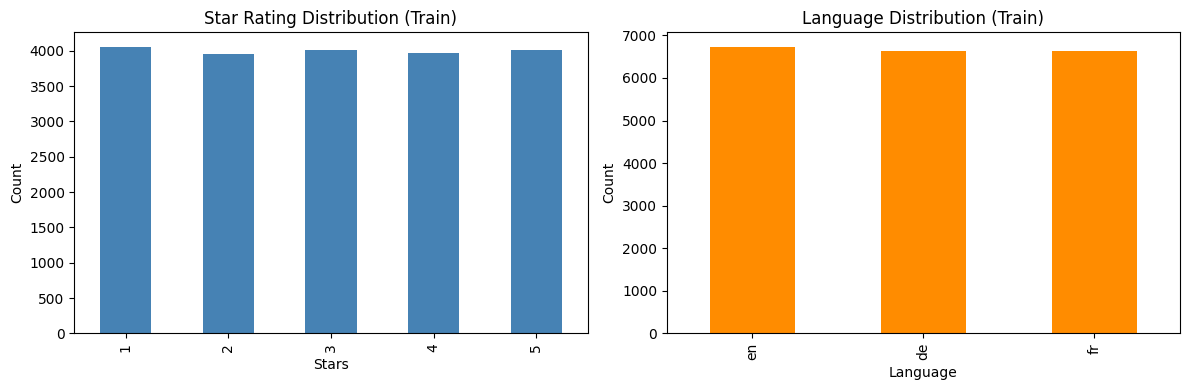

Chart saved to: /content/drive/MyDrive/Enablement/RKC - MSc AI/Mod 01/Assignments/Assignment 02/Working Dataset/star_language_distribution.png

Star counts (train):
 stars
1    4059
2    3960
3    4006
4    3968
5    4007
Name: count, dtype: int64

Language counts (train):
 language
en    6736
de    6634
fr    6630
Name: count, dtype: int64


In [55]:
# ── [3.2] Star rating and language distribution ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['stars'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Star Rating Distribution (Train)')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Count')

train_df['language'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Language Distribution (Train)')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'star_language_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to:", OUTPUT_PATH + 'star_language_distribution.png')
print("\nStar counts (train):\n", train_df['stars'].value_counts().sort_index())
print("\nLanguage counts (train):\n", train_df['language'].value_counts())

=== REVIEW BODY LENGTH (characters) ===
Train:
 count    20000.000000
mean       182.453350
std        172.140038
min         18.000000
25%         75.000000
50%        137.000000
75%        229.000000
max       2903.000000
Name: body_len, dtype: float64

Test:
 count    1500.000000
mean      184.558000
std       184.029843
min        20.000000
25%        79.000000
50%       136.500000
75%       221.000000
max      2343.000000
Name: body_len, dtype: float64


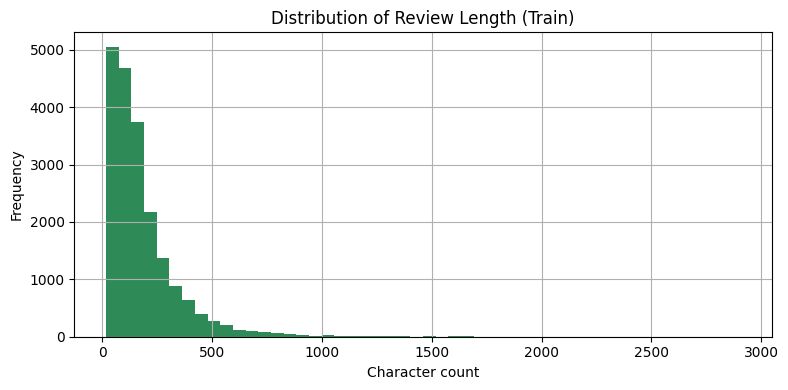

Chart saved to: /content/drive/MyDrive/Enablement/RKC - MSc AI/Mod 01/Assignments/Assignment 02/Working Dataset/review_length_distribution.png


In [56]:
# ── [3.3] Review length statistics ────────────────────────────────────────────
train_df['body_len'] = train_df['review_body'].str.len()
test_df['body_len'] = test_df['review_body'].str.len()

print("=== REVIEW BODY LENGTH (characters) ===")
print("Train:\n", train_df['body_len'].describe())
print("\nTest:\n", test_df['body_len'].describe())

plt.figure(figsize=(8, 4))
train_df['body_len'].hist(bins=50, color='seagreen')
plt.title('Distribution of Review Length (Train)')
plt.xlabel('Character count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to:", OUTPUT_PATH + 'review_length_distribution.png')

=== SENTIMENT CLASS DISTRIBUTION (Train) ===
sentiment
Negative    8019
Positive    7975
Neutral     4006
Name: count, dtype: int64

As percentages:
sentiment
Negative    40.1
Positive    39.9
Neutral     20.0
Name: proportion, dtype: float64

=== SENTIMENT CLASS DISTRIBUTION (Test) ===
sentiment
Positive    612
Negative    596
Neutral     292
Name: count, dtype: int64

As percentages:
sentiment
Positive    40.8
Negative    39.7
Neutral     19.5
Name: proportion, dtype: float64


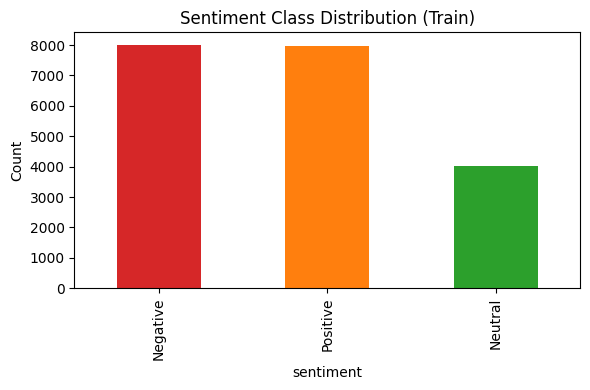

Chart saved to: /content/drive/MyDrive/Enablement/RKC - MSc AI/Mod 01/Assignments/Assignment 02/Working Dataset/sentiment_distribution.png


In [58]:
# ── [3.4] Sentiment mapping preview & class distribution ─────────────────────
# Apply sentiment mapping (preview only — full application happens in Section 4)
# Mapping: 1-2 stars -> Negative, 3 -> Neutral, 4-5 -> Positive
sentiment_map = {1: 'Negative', 2: 'Negative', 3: 'Neutral', 4: 'Positive', 5: 'Positive'}
train_df['sentiment'] = train_df['stars'].map(sentiment_map)
test_df['sentiment']  = test_df['stars'].map(sentiment_map)

print("=== SENTIMENT CLASS DISTRIBUTION (Train) ===")
print(train_df['sentiment'].value_counts())
print("\nAs percentages:")
print((train_df['sentiment'].value_counts(normalize=True) * 100).round(1))

print("\n=== SENTIMENT CLASS DISTRIBUTION (Test) ===")
print(test_df['sentiment'].value_counts())
print("\nAs percentages:")
print((test_df['sentiment'].value_counts(normalize=True) * 100).round(1))

# Visualise
plt.figure(figsize=(6, 4))
train_df['sentiment'].value_counts().plot(
    kind='bar', color=['#d62728', '#ff7f0e', '#2ca02c']
)
plt.title('Sentiment Class Distribution (Train)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to:", OUTPUT_PATH + 'sentiment_distribution.png')

In [59]:
# ── 3.5: Class imbalance quantification ──────────────────────────────────────
counts = train_df['sentiment'].value_counts()
majority = counts.max()

print("=== CLASS IMBALANCE SUMMARY (Train) ===")
for cls, count in counts.items():
    pct_of_majority = (count / majority) * 100
    print(f"{cls:10s}: {count:5d}  ({pct_of_majority:.1f}% of majority class)")

deficit = majority - counts['Neutral']
print(f"\nNeutral class deficit vs majority: {deficit} samples")
print(f"To fully balance, Neutral would need to grow from {counts['Neutral']} to {majority}")

=== CLASS IMBALANCE SUMMARY (Train) ===
Negative  :  8019  (100.0% of majority class)
Positive  :  7975  (99.5% of majority class)
Neutral   :  4006  (50.0% of majority class)

Neutral class deficit vs majority: 4013 samples
To fully balance, Neutral would need to grow from 4006 to 8019


In [60]:
# ── 3.6: Sentiment distribution by language ──────────────────────────────────
print("=== SENTIMENT BY LANGUAGE (Train) ===")
crosstab = pd.crosstab(train_df['language'], train_df['sentiment'])
print(crosstab)

print("\n=== SENTIMENT BY LANGUAGE (% within language) ===")
crosstab_pct = pd.crosstab(train_df['language'], train_df['sentiment'], normalize='index') * 100
print(crosstab_pct.round(1))

=== SENTIMENT BY LANGUAGE (Train) ===
sentiment  Negative  Neutral  Positive
language                              
de             2668     1316      2650
en             2657     1406      2673
fr             2694     1284      2652

=== SENTIMENT BY LANGUAGE (% within language) ===
sentiment  Negative  Neutral  Positive
language                              
de             40.2     19.8      39.9
en             39.4     20.9      39.7
fr             40.6     19.4      40.0


In [61]:
# ── 3.7: Sample reviews per sentiment class ───────────────────────────────────
for sentiment in ['Negative', 'Neutral', 'Positive']:
    print(f"\n{'='*60}")
    print(f"SAMPLE {sentiment.upper()} REVIEWS")
    print('='*60)
    samples = train_df[train_df['sentiment'] == sentiment].sample(2, random_state=RANDOM_SEED)
    for _, row in samples.iterrows():
        print(f"\n[{row['language']}, {row['stars']} stars]: {row['review_body'][:200]}")


SAMPLE NEGATIVE REVIEWS

[en, 2 stars]: I’ll try to add a picture to show how small the XXL version is. I usually wear L to XL shirts and this is supposed to be off the shoulder style. Not even close.

[en, 2 stars]: According to Amcrest website this is a discontinued item. Although everything i have Amcrest works. this box found all my camera's and connected right away.

SAMPLE NEUTRAL REVIEWS

[fr, 3 stars]: Ne grossit pas trop le téléphone. La coque épouse parfaitement ce dernier mais les contours en plastiques sont trop glissant à mon goût. J’ai déjà manqué de faire tomber mon téléphone plusieurs fois.

[de, 3 stars]: Ich habe den Rucksack im Oktober bestellt und jetzt ist mittlerweile der Reißverschluss komplett kaputt. Alles andere sieht noch top aus, bringt nur leider relativ wenig wenn der Rucksack nicht mehr z

SAMPLE POSITIVE REVIEWS

[fr, 5 stars]: vraiment très beau. Correspond à la description et a l'air de bonne qualité. Je l'ai deja porté quelques fois sans mauvaise sur

### Data Audit — Findings Summary

The dataset is clean and well-structured: there are no missing values and no fully duplicate
rows across either the 20,000-row training set or the 1,500-row test set. A small number of
duplicate review bodies (14 in train, 0 in test) were found — short multilingual phrases
(e.g. "Bon rapport qualité prix") that appear with different star ratings from different
reviewers. These are retained as realistic noise rather than removed.

**Languages:** Reviews are roughly evenly split across English, German, and French
(~33% each), in both train and test. This supports a multilingual modelling approach,
which will be tested experimentally against an English-only subset in later sections.

**Star ratings and sentiment mapping:** Star ratings (1-5) are roughly evenly distributed.
No sentiment labels exist in the raw data, so labels are derived using the mapping
1-2 -> Negative, 3 -> Neutral, 4-5 -> Positive. This produces a class distribution of
40.1% Negative, 39.9% Positive, and 20.0% Neutral in the training set, with a near-identical
split in the test set (39.7% / 40.8% / 19.5%).

**Class imbalance:** The Neutral class is consistently around half the size of the other
two classes - not just overall, but within each language individually (19.4%-20.9% across
en/de/fr). This rules out language as the cause of the imbalance and confirms it is an
intrinsic property of the rating distribution (3-star reviews are simply less common than
1-2 or 4-5 star reviews). This imbalance motivates the three class-imbalance strategies
tested in Section 6.

**Review length:** Reviews have a median length of ~137 characters (train) and ~136.5
(test), with a right-skewed distribution (mean > median) and a long tail of much longer
reviews (max ~2,900 characters). Lengths are similar across train and test, suggesting
the test set is representative.

**Implications for the pipeline:** The data requires no cleaning for missing values or
gross duplication. The key challenges are (1) handling three languages in pre-processing
and feature extraction, and (2) addressing the consistent ~2:1 imbalance against the
Neutral class, both of which are treated as explicit experimental variables in this notebook
rather than assumptions.

/# 4.1

## Section 4: Label Engineering

The dataset provides star ratings (1-5) but no sentiment labels. We derive a three-class
sentiment label using the following mapping, based on common conventions for review
sentiment classification:

| Stars | Sentiment |
|-------|-----------|
| 1-2   | Negative  |
| 3     | Neutral   |
| 4-5   | Positive  |

This mapping treats 3-star reviews as genuinely ambiguous/mixed (neither clearly positive
nor negative), which is supported by the sample reviews seen in Section 3 - 3-star reviews
often contain both praise and criticism within the same text. The mapping is applied
identically to train and test sets to ensure consistency.

In [63]:
# 4.2

# ── Section 4: Label Engineering ─────────────────────────────────────────────
# Map star ratings to sentiment labels (already computed during audit, formalised here)

sentiment_map = {1: 'Negative', 2: 'Negative', 3: 'Neutral', 4: 'Positive', 5: 'Positive'}

train_df['sentiment'] = train_df['stars'].map(sentiment_map)
test_df['sentiment'] = test_df['stars'].map(sentiment_map)

# Sanity check: confirm no nulls were introduced (i.e. every star value mapped successfully)
assert train_df['sentiment'].isnull().sum() == 0, "Unmapped stars found in train set"
assert test_df['sentiment'].isnull().sum() == 0, "Unmapped stars found in test set"

print("Label engineering complete.")
print(f"\nTrain sentiment distribution:\n{train_df['sentiment'].value_counts()}")
print(f"\nTest sentiment distribution:\n{test_df['sentiment'].value_counts()}")

# Preview
train_df[['review_body', 'stars', 'sentiment', 'language']].head(5)

Label engineering complete.

Train sentiment distribution:
sentiment
Negative    8019
Positive    7975
Neutral     4006
Name: count, dtype: int64

Test sentiment distribution:
sentiment
Positive    612
Negative    596
Neutral     292
Name: count, dtype: int64


,review_body,stars,sentiment,language
0,"Décevant, la qualité du son de ce vinyle est p...",2,Negative,fr
1,Les caractéristiques inscrites semblent identi...,3,Neutral,fr
2,Great smell and tasting tea. Love the box too.,5,Positive,en
3,Druck etwas pixelig. Sonst schickes Set,4,Positive,de
4,Le disque 6 était défectueux et j'ai perdu 15 ...,2,Negative,fr


\# 4.3

### 4.1: Label Validation — Spot Check

A key assumption in this pipeline is that star ratings reliably reflect the sentiment
expressed in the review text. To partially validate this assumption, we randomly sample
reviews from each sentiment class and manually inspect whether the text tone matches
the derived label.

This is not a substitute for formal inter-annotator agreement scoring, but provides
anecdotal evidence that the star-to-sentiment mapping is reasonable.

In [64]:
# 4.4

# ── 4.1: Label Validation Spot Check ─────────────────────────────────────────
# Randomly sample reviews per sentiment class and display text alongside label.
# Purpose: verify that star-derived sentiment labels reflect actual text tone.

SPOT_CHECK_N = 5  # reviews per class
spot_check_sample = []

print("=" * 70)
print("LABEL VALIDATION SPOT CHECK")
print("Read each review and judge whether the label matches the text tone.")
print("=" * 70)

for sentiment in ['Negative', 'Neutral', 'Positive']:
    print(f"\n{'─' * 70}")
    print(f"CLASS: {sentiment.upper()}")
    print(f"{'─' * 70}")

    samples = train_df[train_df['sentiment'] == sentiment].sample(
        SPOT_CHECK_N, random_state=RANDOM_SEED
    )

    for i, (_, row) in enumerate(samples.iterrows(), 1):
        print(f"\n[{i}] Stars: {row['stars']} | Language: {row['language'].upper()} "
              f"| Category: {row['product_category']}")
        print(f"    {row['review_body'][:300]}")

        spot_check_sample.append({
            'sentiment': sentiment,
            'stars':     row['stars'],
            'language':  row['language'],
            'review':    row['review_body'][:300]
        })

print(f"\n{'=' * 70}")
print("SPOT CHECK COMPLETE")
print(f"Total reviews inspected: {SPOT_CHECK_N * 3}")
print("\nObservation: Record your findings in the markdown cell below.")

LABEL VALIDATION SPOT CHECK
Read each review and judge whether the label matches the text tone.

──────────────────────────────────────────────────────────────────────
CLASS: NEGATIVE
──────────────────────────────────────────────────────────────────────

[1] Stars: 2 | Language: EN | Category: home
    I’ll try to add a picture to show how small the XXL version is. I usually wear L to XL shirts and this is supposed to be off the shoulder style. Not even close.

[2] Stars: 2 | Language: EN | Category: camera
    According to Amcrest website this is a discontinued item. Although everything i have Amcrest works. this box found all my camera's and connected right away.

[3] Stars: 2 | Language: FR | Category: other
    Inspiré d'une histoire vraie, on assiste à un monologue entre trois personnages. Pas d'action et peu de révélations.

[4] Stars: 1 | Language: FR | Category: home_improvement
    Comment dire.... N'achetez surtout pas cet article. Je l'ai choisi car sa date de livraison éta

\# 4.5

### Spot Check Findings

After manually reading 15 sampled reviews across all three sentiment classes:

**Negative class (1–2 stars):** 4 out of 5 samples contained clearly negative
language — common themes included product defects, unmet expectations, and delivery
failures. One sample (Camera, 2 stars) was a notable exception: the review text was
positive in tone ("everything works," "connected right away"), suggesting the low
star rating reflected dissatisfaction with product discontinuation rather than the
product itself. This highlights a known weakness of star-derived labels — customer
ratings are occasionally influenced by factors external to the product experience.

**Neutral class (3 stars):** Only 2 out of 5 samples contained genuinely mixed
language matching the Neutral label. The remaining 3 leaned negative in tone —
describing broken zips, hard-to-follow content, and wrong adapter cables alongside
expressions of disappointment. This finding is significant: 3-star reviews are the
most unreliable class for star-to-sentiment mapping, as customers frequently use
the middle rating as a polite proxy for mild dissatisfaction rather than genuine
neutrality. This partially explains the consistently low Neutral F1 scores observed
across all 12 experiments — the model is not only learning from an underrepresented
class, but from labels that are themselves noisy.

**Positive class (4–5 stars):** 3 out of 5 samples contained clearly positive
language. The remaining 2 showed mixed signals — one noted the product was flimsy
at full extension and overpriced, another expressed disappointment with the logo
despite overall satisfaction. 4-star reviews in particular appear more ambiguous
than 5-star reviews, suggesting the 4–5 boundary for the Positive class may
slightly overstate positivity.

**Overall conclusion:** The star-to-sentiment mapping is most reliable for the
Negative class (4/5 match) and least reliable for the Neutral class (2/5 match).
This assumption is a genuine limitation of the pipeline. Ideally, labels would be
verified through human annotation or inter-annotator agreement scoring. The label
noise in the Neutral class is likely a contributing factor to the low Neutral F1
scores observed throughout the experiments (0.29–0.41), over and above the class
imbalance effect. This is discussed further in Part B.

\# 5.1
## Section 5: Pre-processing

Pre-processing normalises raw review text before feature extraction. Three operations
are applied across all languages (EN, DE, FR):

1. **Lowercasing** — reduces vocabulary size by treating "Good" and "good" as the same token
2. **Punctuation and number removal** — strips characters that carry no semantic value for
   sentiment classification
3. **Whitespace normalisation** — collapses multiple spaces introduced by the above steps

Two common pre-processing steps are deliberately omitted:

- **Stopword removal** — TF-IDF (used in Section 7) mathematically down-weights
  high-frequency, low-information terms, making manual removal redundant. For multilingual
  data, stopword lists are language-specific and introduce ambiguity (some function words
  carry sentiment-relevant meaning in certain languages). With short reviews averaging ~137
  characters, removing tokens also risks stripping meaningful signal.

- **Stemming / lemmatisation** — language-dependent tools (e.g. PorterStemmer for English,
  Cistem for German) would require language detection per review and separate processing
  pipelines per language. Given TF-IDF captures raw term frequency effectively and the
  multilingual scope of this project, the added complexity is not justified.

The test set undergoes identical pre-processing to ensure consistency.

In [65]:
# 5.2

# ── Section 5: Pre-processing ─────────────────────────────────────────────────

def preprocess_text(text):
    """
    Applies language-agnostic pre-processing to a single review string.
    Steps: lowercase -> remove punctuation/numbers -> normalise whitespace.
    No stopword removal or stemming (see markdown above for justification).
    """
    # Step 1: Lowercase
    text = text.lower()
    # Step 2: Remove punctuation and numbers
    text = re.sub(r'[^\w\s]', ' ', text)   # remove punctuation
    text = re.sub(r'\d+', ' ', text)        # remove numbers
    # Step 3: Normalise whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply to train and test
train_df['clean_text'] = train_df['review_body'].apply(preprocess_text)
test_df['clean_text'] = test_df['review_body'].apply(preprocess_text)

print("Pre-processing complete.")
print(f"\nExample: BEFORE -> AFTER")
print(f"\nOriginal: {train_df['review_body'].iloc[0]}")
print(f"\nCleaned:  {train_df['clean_text'].iloc[0]}")

Pre-processing complete.

Example: BEFORE -> AFTER

Original: Décevant, la qualité du son de ce vinyle est plus que moyenne voire misérable...

Cleaned:  décevant la qualité du son de ce vinyle est plus que moyenne voire misérable


In [66]:
# 5.3

# Sanity check: confirm no empty strings after pre-processing
empty_train = (train_df['clean_text'].str.strip() == '').sum()
empty_test = (test_df['clean_text'].str.strip() == '').sum()

print(f"Empty reviews after pre-processing — Train: {empty_train}, Test: {empty_test}")
print(f"\nSample cleaned reviews:")
print(train_df[['review_body', 'clean_text', 'language', 'sentiment']].sample(5, random_state=RANDOM_SEED).to_string())

Empty reviews after pre-processing — Train: 0, Test: 0

Sample cleaned reviews:
                                                                                                                                                                                                                                                                                                                              review_body                                                                                                                                                                                                                                                                                                                  clean_text language sentiment
10650                                                                                                                                                                                                                                                          

\# 6.1
## Section 6: Class Imbalance Strategies

The data audit revealed a consistent class imbalance: the Neutral class represents ~20%
of the training data compared to ~40% each for Positive and Negative. To understand the
effect of this imbalance — and evaluate strategies for addressing it — we create three
training conditions:

- **Condition A (Baseline):** No augmentation. The original imbalanced dataset is used as-is.
  This establishes a performance baseline and quantifies the cost of ignoring imbalance.

- **Condition B (Data Augmentation):** Existing Neutral reviews are augmented using
  random word deletion and random word swap — two lightweight text augmentation techniques
  that preserve the core meaning of a review while introducing lexical variation. This
  strategy works entirely within the existing data.

- **Condition C (Synthetic Data Generation):** Entirely new Neutral reviews are generated
  using the Anthropic API (Claude). Unlike Condition B, these reviews never existed in the
  original dataset. This tests whether high-quality synthetic data can substitute for
  real collected data.

In all three conditions, the **test set remains completely untouched** — ensuring that
evaluation is always performed against real, unmodified reviews, and that comparisons
across conditions are fair.

The target for Conditions B and C is to bring the Neutral class up to match the majority
class size (~8,019 samples), fully balancing the training set.

In [67]:
# 6.2

# ── Section 6: Class Imbalance Strategies ────────────────────────────────────

# ── Condition A: No Augmentation (Baseline) ───────────────────────────────────
# Simply use the pre-processed training data as-is, with the natural imbalance intact.

train_A = train_df[['clean_text', 'sentiment', 'language']].copy()

print("=== CONDITION A: No Augmentation (Baseline) ===")
print(train_A['sentiment'].value_counts())
print(f"\nTotal training samples: {len(train_A)}")

=== CONDITION A: No Augmentation (Baseline) ===
sentiment
Negative    8019
Positive    7975
Neutral     4006
Name: count, dtype: int64

Total training samples: 20000


In [68]:
#6.3

# ── Condition B: Data Augmentation ───────────────────────────────────────────
import random
random.seed(RANDOM_SEED)

def random_word_swap(text):
    """Randomly swap two words in the text."""
    words = text.split()
    if len(words) < 2:
        return text
    idx1, idx2 = random.sample(range(len(words)), 2)
    words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def random_word_deletion(text, deletion_prob=0.1):
    """Randomly delete words with a given probability (minimum 1 word kept)."""
    words = text.split()
    if len(words) == 1:
        return text
    new_words = [w for w in words if random.random() > deletion_prob]
    return ' '.join(new_words) if new_words else words[0]

# Isolate existing Neutral reviews
neutral_df_subset = train_df[train_df['sentiment'] == 'Neutral'].copy()
neutral_reviews   = neutral_df_subset['clean_text'].tolist()
neutral_languages = neutral_df_subset['language'].tolist()

# Calculate how many additional Neutral samples are needed
majority_count = train_A['sentiment'].value_counts().max()
neutral_count  = train_A['sentiment'].value_counts()['Neutral']
deficit        = majority_count - neutral_count

print(f"Majority class size:  {majority_count}")
print(f"Current Neutral size: {neutral_count}")
print(f"Samples to generate:  {deficit}")

# Generate augmented Neutral reviews
augmented_texts     = []
augmented_languages = []

for i in range(deficit):
    source_text = neutral_reviews[i % len(neutral_reviews)]
    source_lang = neutral_languages[i % len(neutral_languages)]
    if i % 2 == 0:
        augmented_texts.append(random_word_swap(source_text))
    else:
        augmented_texts.append(random_word_deletion(source_text))
    augmented_languages.append(source_lang)

# Build augmented Neutral dataframe
augmented_df = pd.DataFrame({
    'clean_text': augmented_texts,
    'sentiment':  'Neutral',
    'language':   augmented_languages
})

# Combine with original training data
train_B = pd.concat([train_A, augmented_df], ignore_index=True)

print(f"\n=== CONDITION B: Data Augmentation ===")
print(train_B['sentiment'].value_counts())
print(f"\nTotal training samples: {len(train_B)}")

# Show a before/after example
sample_original = neutral_reviews[0]
print(f"\nOriginal: {sample_original[:150]}")
print(f"Swapped:  {random_word_swap(sample_original)[:150]}")
print(f"Deleted:  {random_word_deletion(sample_original)[:150]}")

Majority class size:  8019
Current Neutral size: 4006
Samples to generate:  4013

=== CONDITION B: Data Augmentation ===
sentiment
Negative    8019
Neutral     8019
Positive    7975
Name: count, dtype: int64

Total training samples: 24013

Original: les caractéristiques inscrites semblent identiques a l emballage de la photo mais pourquoi alors afficher un autre emballage en photo que celui qu on 
Swapped:  les caractéristiques inscrites semblent identiques a l emballage de la photo mais pourquoi alors afficher photo autre emballage en un que celui qu on 
Deleted:  les caractéristiques inscrites semblent identiques a l emballage de la mais pourquoi alors afficher un autre emballage en photo que celui qu on reçoit


\# 6.4

Neutral is now 8,019 — matching Negative exactly, with Positive close behind at 7,975. Total of 24,013 training samples for Condition B.

In [69]:
# 6.5

# Install Anthropic library
!pip install anthropic --quiet
print("Anthropic library installed.")

Anthropic library installed.


\# 6.6
### Condition C: Synthetic Data Generation

To ensure reproducibility, the notebook first checks for a previously saved set of
synthetic reviews. If found, it loads them directly. If not, it generates new reviews
via the Anthropic API and saves them for future use. This means the API is only called
once, and all subsequent runs use identical synthetic data.

In [74]:
# ── [6.7] Condition C: Load existing synthetic reviews or generate new ones ───
import os
import json
import time
import anthropic
from google.colab import userdata

SAVE_PATH = OUTPUT_PATH + 'synthetic_neutral_reviews.csv'

if os.path.exists(SAVE_PATH):
    # ── Existing file found — ask user ────────────────────────────────────────
    print(f"Found existing synthetic reviews at:\n  {SAVE_PATH}")
    choice = input("\nEnter L to load existing reviews, R to regenerate: ").strip().upper()

    if choice == 'R':
        # Fall through to generation block below
        run_generation = True
        print("\nRegenerating synthetic reviews...")
    else:
        # Load existing
        run_generation = False
        print("\nLoading existing synthetic reviews...")
        synthetic_df = pd.read_csv(SAVE_PATH)
        all_synthetic_texts     = synthetic_df['clean_text'].tolist()
        all_synthetic_languages = synthetic_df['language'].tolist()
        print(f"Loaded {len(synthetic_df)} synthetic reviews.")
        print(f"Language distribution:\n{synthetic_df['language'].value_counts()}")
else:
    run_generation = True
    print("No existing synthetic reviews found — generating via Anthropic API...")

if run_generation:
    # ── Generate new synthetic reviews via Anthropic API ──────────────────────
    api_key = userdata.get('ANTHROPIC_API_KEY')
    client  = anthropic.Anthropic(api_key=api_key)

    LANGUAGES        = {'en': 'English', 'de': 'German', 'fr': 'French'}
    BATCH_SIZE       = 10
    TARGET           = deficit
    reviews_per_lang = TARGET // len(LANGUAGES)

    def generate_neutral_reviews(language_code, language_name, count, batch_size=BATCH_SIZE):
        """
        Generate neutral (3-star equivalent) product reviews in the specified language.
        Returns a list of cleaned review strings.
        """
        reviews = []
        batches = (count + batch_size - 1) // batch_size

        for batch_idx in range(batches):
            remaining  = count - len(reviews)
            this_batch = min(batch_size, remaining)

            prompt = f"""Generate exactly {this_batch} realistic neutral product reviews in {language_name}.

These reviews should reflect a 3-star experience: the product is neither clearly good nor bad.
They should contain a mix of mild praise and mild criticism, or simply be indifferent.
Reviews should vary in length (1-4 sentences), topic (electronics, clothing, food, accessories),
and phrasing. Do not number them.

Return ONLY a JSON array of strings, with no explanation, no preamble, no markdown formatting.
Example format: ["review one", "review two"]"""

            try:
                response = client.messages.create(
                    model="claude-sonnet-4-6",
                    max_tokens=1000,
                    messages=[{"role": "user", "content": prompt}]
                )
                raw           = response.content[0].text.strip()
                batch_reviews = json.loads(raw)
                reviews.extend(batch_reviews[:this_batch])

            except Exception as e:
                print(f"  Error in batch {batch_idx + 1}: {e}")
                time.sleep(2)
                continue

            if (batch_idx + 1) % 10 == 0:
                print(f"  [{language_name}] {len(reviews)}/{count} reviews generated...")

            time.sleep(0.3)

        return reviews[:count]

    # Generate per language
    all_synthetic_texts     = []
    all_synthetic_languages = []

    for lang_code, lang_name in LANGUAGES.items():
        print(f"Generating {reviews_per_lang} {lang_name} reviews...")
        generated = generate_neutral_reviews(lang_code, lang_name, reviews_per_lang)
        all_synthetic_texts.extend(generated)
        all_synthetic_languages.extend([lang_code] * len(generated))
        print(f"  Done: {len(generated)} {lang_name} reviews generated.")

    # Handle shortfall
    shortfall = TARGET - len(all_synthetic_texts)
    if shortfall > 0:
        print(f"\nGenerating {shortfall} additional English reviews to meet target...")
        extra = generate_neutral_reviews('en', 'English', shortfall)
        all_synthetic_texts.extend(extra)
        all_synthetic_languages.extend(['en'] * len(extra))

    print(f"\nTotal synthetic reviews generated: {len(all_synthetic_texts)}")

    # Pre-process and save
    synthetic_clean = [preprocess_text(r) for r in all_synthetic_texts]
    synthetic_df    = pd.DataFrame({
        'clean_text': synthetic_clean,
        'sentiment':  'Neutral',
        'language':   all_synthetic_languages
    })

    synthetic_df.to_csv(SAVE_PATH, index=False)
    print(f"\nSaved to: {SAVE_PATH}")

Found existing synthetic reviews at:
  /content/drive/MyDrive/Enablement/RKC - MSc AI/Mod 01/Assignments/Assignment 02/Working Dataset/synthetic_neutral_reviews.csv

Enter L to load existing reviews, R to regenerate: L

Loading existing synthetic reviews...
Loaded 4013 synthetic reviews.
Language distribution:
language
en    1339
de    1337
fr    1337
Name: count, dtype: int64


In [75]:
# ── [6.8] Pre-process synthetic reviews (same pipeline as Section 5)
synthetic_clean = [preprocess_text(r) for r in all_synthetic_texts]

# Build synthetic Neutral dataframe
synthetic_df = pd.DataFrame({
    'clean_text': synthetic_clean,
    'sentiment':  'Neutral',
    'language':   all_synthetic_languages
})

# Combine with original training data
train_C = pd.concat([train_A, synthetic_df], ignore_index=True)

print("=== CONDITION C: Synthetic Data Generation ===")
print(train_C['sentiment'].value_counts())
print(f"\nTotal training samples: {len(train_C)}")
print(f"\nLanguage distribution of synthetic reviews:")
print(synthetic_df['language'].value_counts())

# Show sample synthetic reviews
print(f"\nSample synthetic reviews:")
for lang in ['en', 'de', 'fr']:
    sample = synthetic_df[synthetic_df['language'] == lang]['clean_text'].iloc[0]
    print(f"\n[{lang}]: {sample[:200]}")

=== CONDITION C: Synthetic Data Generation ===
sentiment
Negative    8019
Neutral     8019
Positive    7975
Name: count, dtype: int64

Total training samples: 24013

Language distribution of synthetic reviews:
language
en    1339
de    1337
fr    1337
Name: count, dtype: int64

Sample synthetic reviews:

[en]: the headphones work fine for casual listening but the ear cushions feel a bit cheap and started peeling after a few months not bad for the price but i expected better build quality

[de]: das headset funktioniert soweit ganz ordentlich aber der tragekomfort lässt nach längerer zeit zu wünschen übrig für den preis ist es in ordnung mehr aber auch nicht

[fr]: le produit est conforme à la description ni plus ni moins la qualité semble correcte pour le prix mais je ne suis pas sûr de le recommander à un ami


\# 7.1
## Section 7: Feature Extraction

Machine learning models cannot process raw text directly — text must be converted into
numerical representations. We use **TF-IDF (Term Frequency–Inverse Document Frequency)**
vectorisation for this purpose.

TF-IDF assigns each word a score based on two factors:
- **TF (Term Frequency):** how often a word appears in a specific review
- **IDF (Inverse Document Frequency):** how rarely a word appears across all reviews

A word scores highly only if it is frequent in a specific review but rare across the
dataset — capturing words that are genuinely distinctive to that document rather than
common filler terms.

**Key implementation decisions:**

- **Fitted separately per condition (A, B, C):** Each training condition has a different
  set of documents (particularly in the Neutral class), so IDF weights must reflect each
  condition's own vocabulary. Fitting a shared vectoriser would contaminate conditions
  with each other's word frequencies.

- **Fitted on training data only:** The test set never influences the IDF weights. Allowing
  test data to inform the vectoriser would constitute data leakage — the model would gain
  indirect knowledge of unseen data, inflating evaluation scores artificially.

- **Language scope:** For each condition, we fit two vectorisers — one on the English-only
  subset and one on the full multilingual dataset — producing six TF-IDF representations
  in total (3 conditions × 2 language scopes).

- **max_features=50,000:** Caps the vocabulary size to the 50,000 most frequent terms,
  balancing representational richness against computational cost.

In [21]:
# 7.2

# ── Section 7: Feature Extraction ────────────────────────────────────────────
# Fit TF-IDF vectorisers separately for each condition and language scope.
# Transform both training and test sets using each fitted vectoriser.
# Result: 6 vectorisers and 6 pairs of (X_train, X_test) matrices.

# Fixed test set — identical for all conditions and language scopes
test_en   = test_df[test_df['language'] == 'en']
test_multi = test_df  # all languages

# Labels for test sets
y_test_en    = test_en['sentiment']
y_test_multi = test_multi['sentiment']

# Store all vectorisers and transformed datasets in dictionaries
vectorisers = {}
X_trains    = {}
X_tests     = {}
y_trains    = {}

# Define conditions and their training dataframes
conditions = {
    'A': train_A,
    'B': train_B,
    'C': train_C
}

for cond_name, train_data in conditions.items():
    # ── English Only ──────────────────────────────────────────────────────────
    train_en = train_data[train_data['language'] == 'en']

    tfidf_en = TfidfVectorizer(max_features=50000)
    X_train_en = tfidf_en.fit_transform(train_en['clean_text'])
    X_test_en  = tfidf_en.transform(test_en['clean_text'])

    key_en = f"{cond_name}_en"
    vectorisers[key_en] = tfidf_en
    X_trains[key_en]    = X_train_en
    X_tests[key_en]     = X_test_en
    y_trains[key_en]    = train_en['sentiment']

    # ── Multilingual ──────────────────────────────────────────────────────────
    tfidf_multi = TfidfVectorizer(max_features=50000)
    X_train_multi = tfidf_multi.fit_transform(train_data['clean_text'])
    X_test_multi  = tfidf_multi.transform(test_multi['clean_text'])

    key_multi = f"{cond_name}_multi"
    vectorisers[key_multi] = tfidf_multi
    X_trains[key_multi]    = X_train_multi
    X_tests[key_multi]     = X_test_multi
    y_trains[key_multi]    = train_data['sentiment']

print("=== TF-IDF VECTORISATION COMPLETE ===")
print(f"\n{'Key':<12} {'Train shape':<25} {'Test shape':<25} {'Vocabulary size'}")
print("-" * 80)
for key in X_trains:
    scope     = "EN only" if key.endswith("_en") else "Multilingual"
    print(f"{key:<12} {str(X_trains[key].shape):<25} {str(X_tests[key].shape):<25} {len(vectorisers[key].vocabulary_)}")

=== TF-IDF VECTORISATION COMPLETE ===

Key          Train shape               Test shape                Vocabulary size
--------------------------------------------------------------------------------
A_en         (6736, 11053)             (460, 11053)              11053
A_multi      (20000, 38036)            (1500, 38036)             38036
B_en         (8147, 11053)             (460, 11053)              11053
B_multi      (24013, 38036)            (1500, 38036)             38036
C_en         (8075, 11174)             (460, 11174)              11174
C_multi      (24013, 38584)            (1500, 38584)             38584


\# 8.1

## Section 8: Experiments

We run a structured grid of experiments across:
- **2 models:** Logistic Regression (classical) and MLP Neural Network (neural)
- **3 conditions:** A (no augmentation), B (data augmentation), C (synthetic data)
- **2 language scopes:** English-only and Multilingual

This produces **12 model runs in total.** Each run records:
- Accuracy
- Weighted F1-score
- Per-class F1-score (Positive, Negative, Neutral separately)
- Confusion matrix

The test set is identical and untouched across all runs, ensuring fair comparison.
Results are stored in a structured list for analysis in Section 9.

| | No Augmentation (A) | Data Augmentation (B) | Synthetic Data (C) |
|---|---|---|---|
| **English Only** | Exp 1 | Exp 3 | Exp 5 |
| **Multilingual** | Exp 2 | Exp 4 | Exp 6 |

Each experiment runs both models (LR + MLP) = 12 runs total.

In [76]:
# ── [8.2] Section 8: Experiments — Model Definitions ─────────────────────────
# Models are instantiated fresh for each experiment run via get_fresh_models()
# in Cell [8.3]. Definitions here are for reference and documentation only.

# Model 1: Logistic Regression (classical baseline)
# - class_weight='balanced' compensates for Neutral class imbalance
# - max_iter=1000 ensures convergence on larger multilingual datasets
# - Handles sparse TF-IDF matrices natively

# Model 2: MLP Neural Network
# - Two hidden layers (256 → 128 neurons) with ReLU activation
# - early_stopping=False and .toarray() conversion used in Cell [8.3]
#   to resolve scikit-learn sparse matrix compatibility issue
# - max_iter=100 with no early stopping

# Results storage — holds all 12 experiment outputs
results = []

print("Experiment configuration:")
print("  Models:           Logistic Regression, MLP Neural Network")
print("  Conditions:       A (No Augmentation), B (Data Augmentation), C (Synthetic)")
print("  Language scopes:  English Only, Multilingual")
print("  Total runs:       12")
print("\nReady to proceed to Cell [8.3].")

Experiment configuration:
  Models:           Logistic Regression, MLP Neural Network
  Conditions:       A (No Augmentation), B (Data Augmentation), C (Synthetic)
  Language scopes:  English Only, Multilingual
  Total runs:       12

Ready to proceed to Cell [8.3].


In [78]:
# ── [8.3] Load existing results or run all experiments ───────────────────────
import pickle
import os

RESULTS_CSV_PATH = OUTPUT_PATH + 'experiment_results.csv'
RESULTS_PKL_PATH = OUTPUT_PATH + 'experiment_results.pkl'

def run_all_experiments():
    """Run the full 12-experiment grid and return results list."""

    def get_fresh_models():
        return {
            'Logistic Regression': LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_SEED,
                class_weight='balanced'
            ),
            'MLP': MLPClassifier(
                hidden_layer_sizes=(256, 128),
                activation='relu',
                max_iter=100,
                random_state=RANDOM_SEED,
                early_stopping=False
            )
        }

    condition_labels = {'A': 'No Augmentation', 'B': 'Data Augmentation', 'C': 'Synthetic Data'}
    scope_labels     = {'en': 'English Only', 'multi': 'Multilingual'}
    y_tests          = {'en': y_test_en, 'multi': y_test_multi}

    _results   = []
    exp_number = 1

    for condition in ['A', 'B', 'C']:
        for scope in ['en', 'multi']:
            key     = f"{condition}_{scope}"
            X_train = X_trains[key]
            X_test  = X_tests[key]
            y_train = y_trains[key]
            y_test  = y_tests[scope]

            for model_name, model in get_fresh_models().items():
                print(f"Running Exp {exp_number}: {condition_labels[condition]} | "
                      f"{scope_labels[scope]} | {model_name}...")

                X_train_fit = X_train.toarray() if model_name == 'MLP' else X_train
                X_test_pred = X_test.toarray()  if model_name == 'MLP' else X_test

                model.fit(X_train_fit, y_train)
                y_pred = model.predict(X_test_pred)

                acc         = accuracy_score(y_test, y_pred)
                f1_weighted = f1_score(y_test, y_pred, average='weighted')
                report      = classification_report(y_test, y_pred, output_dict=True)
                cm          = confusion_matrix(y_test, y_pred,
                                               labels=['Negative', 'Neutral', 'Positive'])

                _results.append({
                    'Exp':         exp_number,
                    'Condition':   condition_labels[condition],
                    'Scope':       scope_labels[scope],
                    'Model':       model_name,
                    'Accuracy':    round(acc, 4),
                    'F1_weighted': round(f1_weighted, 4),
                    'F1_Negative': round(report['Negative']['f1-score'], 4),
                    'F1_Neutral':  round(report['Neutral']['f1-score'], 4),
                    'F1_Positive': round(report['Positive']['f1-score'], 4),
                    'CM':          cm
                })

                print(f"  Accuracy: {acc:.4f} | Weighted F1: {f1_weighted:.4f}")
                exp_number += 1

    print(f"\nAll {exp_number - 1} experiments complete.")
    return _results

def load_from_pkl(pkl_path):
    """Load full results including confusion matrices from a pickle file."""
    with open(pkl_path, 'rb') as f:
        return pickle.load(f)

def load_from_csv(csv_path):
    """
    Load results from CSV (no confusion matrices).
    Confusion matrices will be unavailable — noted in output.
    """
    df = pd.read_csv(csv_path)
    _results = df.to_dict('records')
    for r in _results:
        r['CM'] = None
    print("Note: confusion matrices are not available when loading from CSV.")
    return _results

# ── Decision logic ────────────────────────────────────────────────────────────
results     = None
results_df  = None
freshly_run = False

# Option 1: Check for pickle file (full results with confusion matrices)
if os.path.exists(RESULTS_PKL_PATH):
    print(f"Found saved results (pickle) at:\n  {RESULTS_PKL_PATH}")
    choice = input("\nEnter L to load existing results, R to re-run all experiments: ").strip().upper()

    if choice == 'R':
        results     = run_all_experiments()
        freshly_run = True
    else:
        print("\nLoading results from pickle...")
        results     = load_from_pkl(RESULTS_PKL_PATH)
        freshly_run = False
        print(f"Loaded {len(results)} experiment results (including confusion matrices).")

# Option 2: Check for CSV file (results without confusion matrices)
elif os.path.exists(RESULTS_CSV_PATH):
    print(f"Found saved results (CSV) at:\n  {RESULTS_CSV_PATH}")
    choice = input("\nEnter L to load existing results, R to re-run all experiments: ").strip().upper()

    if choice == 'R':
        results     = run_all_experiments()
        freshly_run = True
    else:
        print("\nLoading results from CSV...")
        results     = load_from_csv(RESULTS_CSV_PATH)
        freshly_run = False
        print(f"Loaded {len(results)} experiment results.")

# Option 3: No saved results — offer upload or run
else:
    print("No saved results found.")
    print("Options:")
    print("  R — Run all 12 experiments now")
    print("  U — Upload a saved results file (.pkl or .csv)")
    choice = input("\nEnter R or U: ").strip().upper()

    if choice == 'U':
        from google.colab import files as colab_files
        print("\nUpload your results file (.pkl preferred, .csv accepted):")
        uploaded_file = colab_files.upload()
        filename      = list(uploaded_file.keys())[0]

        if filename.endswith('.pkl'):
            results = load_from_pkl(filename)
            print(f"Loaded {len(results)} results from uploaded pickle file.")
        elif filename.endswith('.csv'):
            results = load_from_csv(filename)
            print(f"Loaded {len(results)} results from uploaded CSV file.")
        else:
            print("Unrecognised file type. Running experiments instead.")
            results     = run_all_experiments()
            freshly_run = True
    else:
        results     = run_all_experiments()
        freshly_run = True

# ── Build results dataframe ───────────────────────────────────────────────────
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'CM'} for r in results])

print("\n=== RESULTS LOADED ===")
print(f"Total experiments: {len(results_df)}")
print(f"Freshly run:       {freshly_run}")
display(results_df[['Exp', 'Condition', 'Scope', 'Model',
                     'Accuracy', 'F1_weighted',
                     'F1_Negative', 'F1_Neutral', 'F1_Positive']])

Found saved results (pickle) at:
  /content/drive/MyDrive/Enablement/RKC - MSc AI/Mod 01/Assignments/Assignment 02/Working Dataset/experiment_results.pkl

Enter L to load existing results, R to re-run all experiments: L

Loading results from pickle...
Loaded 12 experiment results (including confusion matrices).

=== RESULTS LOADED ===
Total experiments: 12
Freshly run:       False


,Exp,Condition,Scope,Model,Accuracy,F1_weighted,F1_Negative,F1_Neutral,F1_Positive
0,1,No Augmentation,English Only,Logistic Regression,0.6674,0.6786,0.7317,0.3689,0.7768
1,2,No Augmentation,English Only,MLP,0.6196,0.6211,0.6846,0.3152,0.7068
2,3,No Augmentation,Multilingual,Logistic Regression,0.6773,0.6858,0.7380,0.4073,0.7678
3,4,No Augmentation,Multilingual,MLP,0.6487,0.6399,0.7075,0.3250,0.7244
4,5,Data Augmentation,English Only,Logistic Regression,0.6674,0.6791,0.7248,0.3671,0.7861
5,6,Data Augmentation,English Only,MLP,0.6304,0.6283,0.6984,0.3086,0.7139
6,7,Data Augmentation,Multilingual,Logistic Regression,0.6773,0.6863,0.7374,0.4024,0.7721
7,8,Data Augmentation,Multilingual,MLP,0.6407,0.6408,0.7009,0.3509,0.7205
8,9,Synthetic Data,English Only,Logistic Regression,0.6935,0.6819,0.7506,0.2930,0.8033
9,10,Synthetic Data,English Only,MLP,0.6261,0.6250,0.6909,0.3390,0.6983


In [77]:
# ── [8b.1] Save results to Google Drive ──────────────────────────────────────
# Saves results only if experiments were freshly run in Cell [8.3].
# If results were loaded from file, no overwrite is performed.

if 'freshly_run' in dir() and freshly_run:
    # Save full results including confusion matrices
    with open(RESULTS_PKL_PATH, 'wb') as f:
        pickle.dump(results, f)
    print(f"Full results saved:    {RESULTS_PKL_PATH}")

    # Save summary CSV
    results_df.to_csv(RESULTS_CSV_PATH, index=False)
    print(f"Summary CSV saved:     {RESULTS_CSV_PATH}")
    print(f"Total experiments saved: {len(results_df)}")
else:
    print("Results were loaded from file — no overwrite performed.")

Results were loaded from file — no overwrite performed.


\# 9.1

## Section 9: Results & Comparison

This section presents a structured analysis of all 12 experiment results across three
dimensions:

1. **Model comparison** — Logistic Regression vs MLP across all conditions
2. **Language scope effect** — English-only vs Multilingual
3. **Augmentation strategy effect** — No Augmentation vs Data Augmentation vs Synthetic Data

A particular focus is placed on the Neutral class, which proved consistently the most
challenging across all experiments — a direct consequence of the class imbalance
identified in the data audit and the inherent ambiguity of 3-star reviews.

In [80]:
# ── 9.2: Full results summary table ──────────────────────────────────────────
print("=== FULL RESULTS SUMMARY (sorted by Weighted F1) ===\n")
results_sorted = results_df.sort_values('F1_weighted', ascending=False).reset_index(drop=True)
display(results_sorted[['Exp', 'Condition', 'Scope', 'Model',
                         'Accuracy', 'F1_weighted',
                         'F1_Negative', 'F1_Neutral', 'F1_Positive']])

=== FULL RESULTS SUMMARY (sorted by Weighted F1) ===



,Exp,Condition,Scope,Model,Accuracy,F1_weighted,F1_Negative,F1_Neutral,F1_Positive
0,7,Data Augmentation,Multilingual,Logistic Regression,0.6773,0.6863,0.7374,0.4024,0.7721
1,3,No Augmentation,Multilingual,Logistic Regression,0.6773,0.6858,0.7380,0.4073,0.7678
2,9,Synthetic Data,English Only,Logistic Regression,0.6935,0.6819,0.7506,0.2930,0.8033
3,5,Data Augmentation,English Only,Logistic Regression,0.6674,0.6791,0.7248,0.3671,0.7861
4,1,No Augmentation,English Only,Logistic Regression,0.6674,0.6786,0.7317,0.3689,0.7768
5,11,Synthetic Data,Multilingual,Logistic Regression,0.6860,0.6757,0.7506,0.3152,0.7748
6,8,Data Augmentation,Multilingual,MLP,0.6407,0.6408,0.7009,0.3509,0.7205
7,4,No Augmentation,Multilingual,MLP,0.6487,0.6399,0.7075,0.3250,0.7244
8,6,Data Augmentation,English Only,MLP,0.6304,0.6283,0.6984,0.3086,0.7139
9,10,Synthetic Data,English Only,MLP,0.6261,0.6250,0.6909,0.3390,0.6983


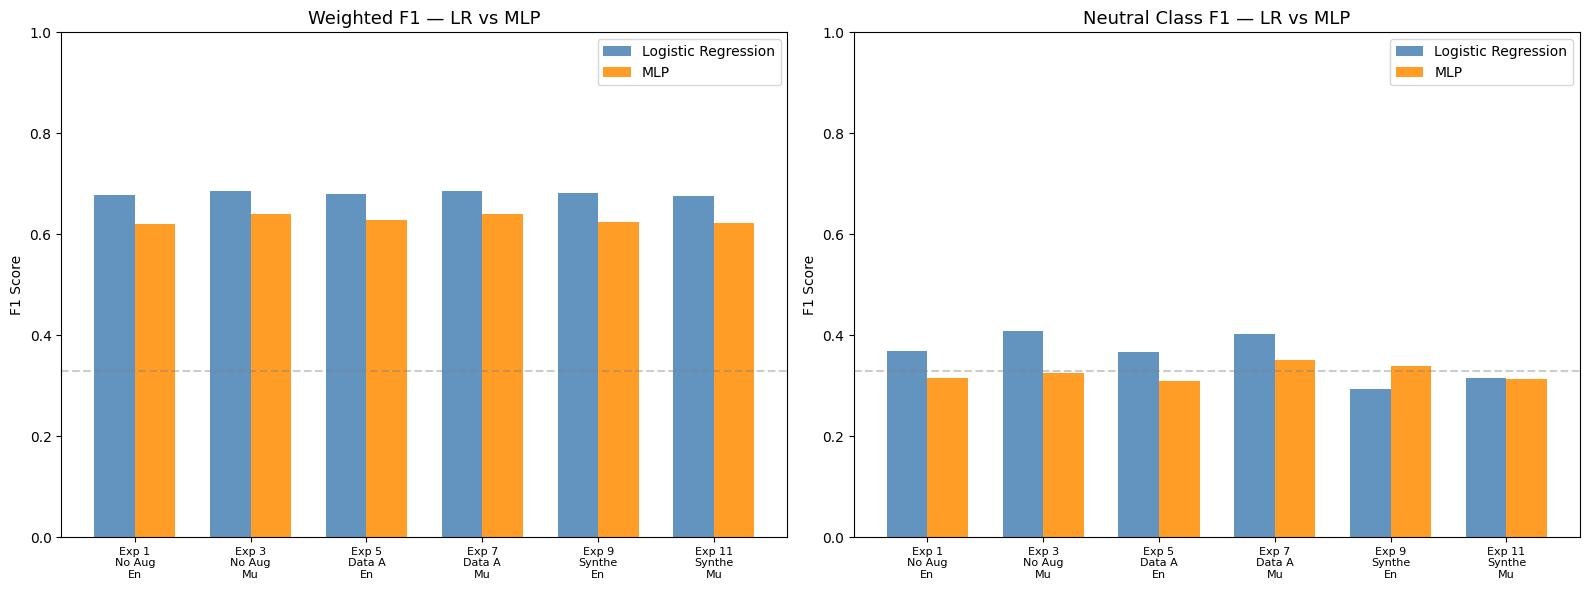

Chart saved to Google Drive: model_comparison.png


In [37]:
# ── 9.3: Model comparison — LR vs MLP ────────────────────────────────────────
lr_results  = results_df[results_df['Model'] == 'Logistic Regression'].reset_index(drop=True)
mlp_results = results_df[results_df['Model'] == 'MLP'].reset_index(drop=True)

x      = np.arange(len(lr_results))
width  = 0.35
labels = [f"Exp {r['Exp']}\n{r['Condition'][:6]}\n{r['Scope'][:2]}"
          for _, r in lr_results.iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title in zip(
    axes,
    ['F1_weighted', 'F1_Neutral'],
    ['Weighted F1 — LR vs MLP', 'Neutral Class F1 — LR vs MLP']
):
    ax.bar(x - width/2, lr_results[metric],  width,
           label='Logistic Regression', color='steelblue', alpha=0.85)
    ax.bar(x + width/2, mlp_results[metric], width,
           label='MLP', color='darkorange', alpha=0.85)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.legend()
    ax.axhline(y=0.33, color='grey', linestyle='--', alpha=0.4, label='Random baseline')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Google Drive: model_comparison.png")

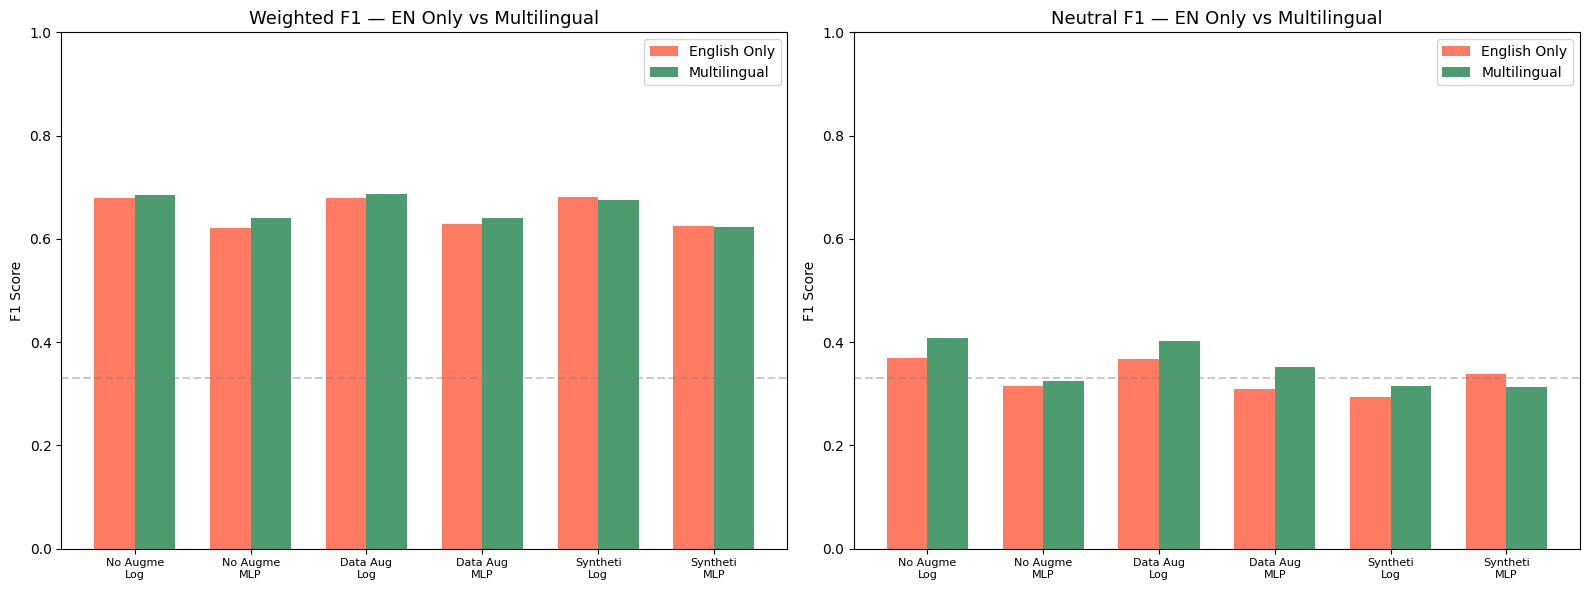

Chart saved to Google Drive: language_scope_effect.png


In [38]:
# ── 9.4: Language scope effect ────────────────────────────────────────────────
en_results    = results_df[results_df['Scope'] == 'English Only'].reset_index(drop=True)
multi_results = results_df[results_df['Scope'] == 'Multilingual'].reset_index(drop=True)

x      = np.arange(len(en_results))
width  = 0.35
labels = [f"{r['Condition'][:8]}\n{r['Model'][:3]}"
          for _, r in en_results.iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title in zip(
    axes,
    ['F1_weighted', 'F1_Neutral'],
    ['Weighted F1 — EN Only vs Multilingual', 'Neutral F1 — EN Only vs Multilingual']
):
    ax.bar(x - width/2, en_results[metric],    width,
           label='English Only', color='tomato',   alpha=0.85)
    ax.bar(x + width/2, multi_results[metric], width,
           label='Multilingual', color='seagreen', alpha=0.85)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.legend()
    ax.axhline(y=0.33, color='grey', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'language_scope_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Google Drive: language_scope_effect.png")

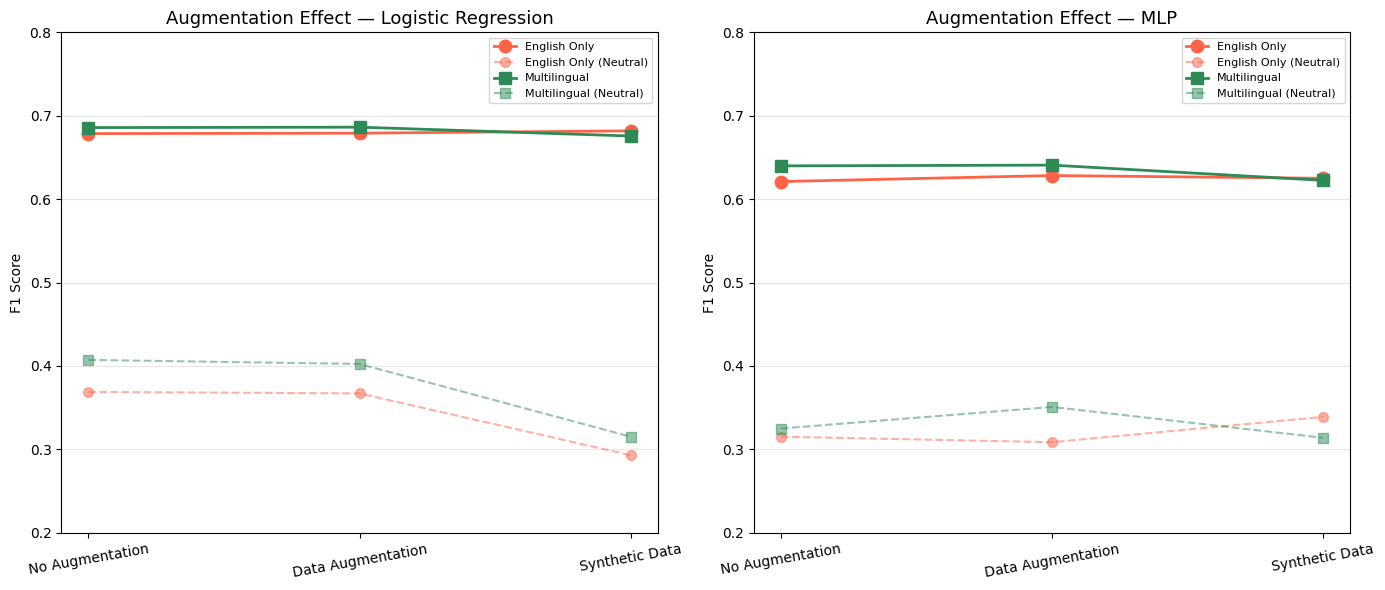

Chart saved to Google Drive: augmentation_effect.png


In [39]:
# ── 9.5: Augmentation strategy effect ────────────────────────────────────────
conditions_order = ['No Augmentation', 'Data Augmentation', 'Synthetic Data']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model_name in zip(axes, ['Logistic Regression', 'MLP']):
    for scope, colour, marker in [
        ('English Only', 'tomato',   'o'),
        ('Multilingual', 'seagreen', 's')
    ]:
        subset = (results_df[
            (results_df['Model'] == model_name) &
            (results_df['Scope'] == scope)
        ].set_index('Condition')
         .reindex(conditions_order))

        ax.plot(conditions_order, subset['F1_weighted'],
                marker=marker, linestyle='-',
                label=scope, linewidth=2, markersize=9, color=colour)
        ax.plot(conditions_order, subset['F1_Neutral'],
                marker=marker, linestyle='--',
                label=f'{scope} (Neutral)', linewidth=1.5,
                markersize=7, color=colour, alpha=0.5)

    ax.set_title(f'Augmentation Effect — {model_name}', fontsize=13)
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0.2, 0.8)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'augmentation_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Google Drive: augmentation_effect.png")

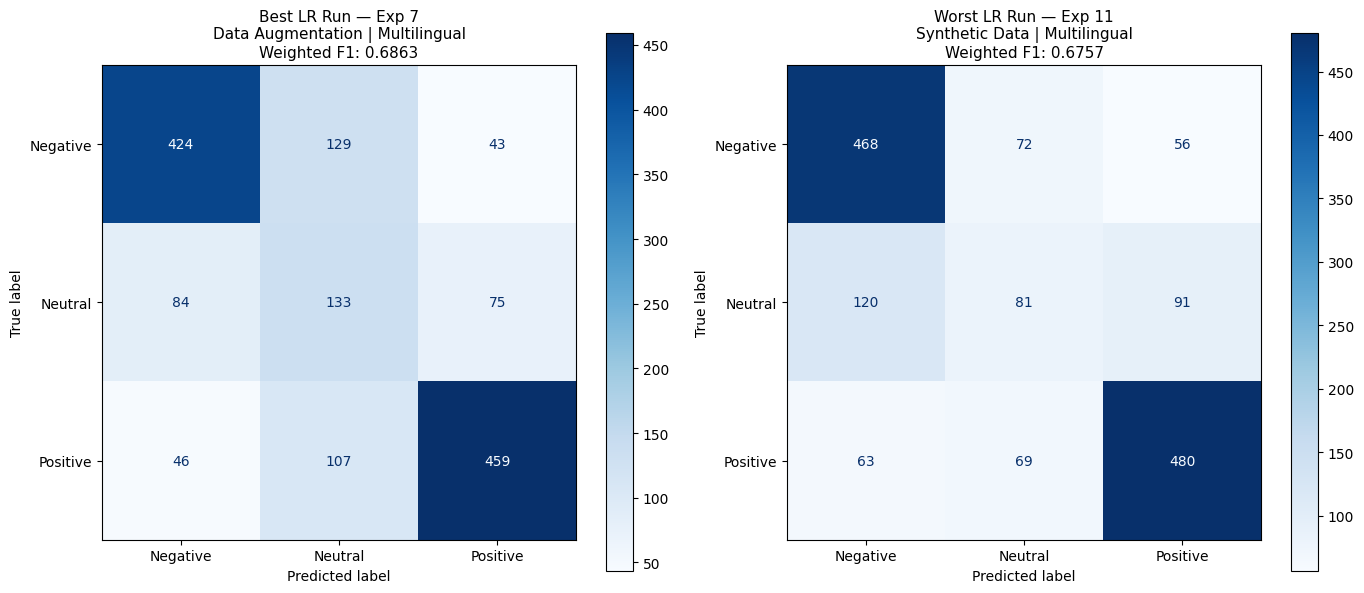

Chart saved to Google Drive: confusion_matrices_lr.png


In [40]:
# ── 9.6: Confusion matrices — best and worst LR runs ─────────────────────────
lr_results_full = [r for r in results if r['Model'] == 'Logistic Regression']
best_lr  = max(lr_results_full, key=lambda x: x['F1_weighted'])
worst_lr = min(lr_results_full, key=lambda x: x['F1_weighted'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, exp, label in zip(axes,
                           [best_lr, worst_lr],
                           ['Best LR Run', 'Worst LR Run']):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=exp['CM'],
        display_labels=['Negative', 'Neutral', 'Positive']
    )
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(
        f"{label} — Exp {exp['Exp']}\n"
        f"{exp['Condition']} | {exp['Scope']}\n"
        f"Weighted F1: {exp['F1_weighted']}",
        fontsize=11
    )

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'confusion_matrices_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Google Drive: confusion_matrices_lr.png")

\# 9.7

### Key Findings from Experiments

**1. Logistic Regression outperforms MLP across all 12 experiments.**
LR weighted F1 ranges from 0.676–0.686 across all conditions, while MLP ranges
from 0.621–0.641. This result is consistent and unsurprising: TF-IDF produces
sparse, high-dimensional feature vectors for which Logistic Regression is
particularly well-suited. MLP neural networks typically require denser,
contextually richer representations — such as word embeddings — to outperform
classical methods on text classification tasks.

**2. Multilingual training consistently outperforms English-only for Logistic Regression.**
Across all three augmentation conditions, multilingual LR achieves higher weighted
F1 than its English-only counterpart. This empirically validates the decision to
adopt a multilingual approach — more training data across all three languages
improves generalisation without requiring separate per-language models.

**3. Augmentation strategies had minimal impact on overall Logistic Regression performance.**
Weighted F1 for LR varies by less than 0.01 across Conditions A, B, and C in both
language scopes. This suggests the performance ceiling for TF-IDF + LR is determined
by the quality of feature representation rather than training data quantity. Adding
more Neutral samples — whether augmented or synthetic — does not meaningfully shift
the model's overall behaviour when the underlying features remain bag-of-words counts.

**4. Synthetic data (Condition C) produced the most counterintuitive result.**
Despite generating 4,013 new Neutral reviews, Condition C produced the lowest Neutral
class F1 scores across LR experiments (EN: 0.293, Multi: 0.315) — lower than the
imbalanced baseline (Condition A). This suggests that synthetically generated reviews,
while linguistically fluent, may occupy a subtly different region of the TF-IDF feature
space compared to real 3-star reviews. The model appears to have learned a Neutral
boundary that does not generalise well to real ambiguous reviews, despite the
additional training signal.

**5. The Neutral class is consistently the hardest to classify across all experiments.**
Neutral F1 ranges from 0.29–0.41 across all 12 runs, compared to 0.68–0.75 for
Negative and 0.70–0.80 for Positive. This reflects both the persistent class imbalance
(Neutral represents only ~20% of real reviews) and the inherent semantic ambiguity of
3-star reviews, which frequently contain mixed positive and negative signals within
the same text — making them genuinely difficult to distinguish from both adjacent classes
using bag-of-words features alone.

\# 8c.1

## Section 8c: Hyperparameter Tuning — Improvement Attempt

The baseline Logistic Regression model used default hyperparameters, which are rarely
optimal for a specific dataset. GridSearchCV systematically searches a defined grid of
parameter combinations, evaluating each using cross-validation, and selects the
combination that maximises performance.

**Why Logistic Regression was chosen for tuning:**
- LR consistently outperformed MLP across all 12 baseline experiments
- LR is well-suited to sparse TF-IDF features — tuning it is more likely to yield
  meaningful gains than tuning MLP, which is fundamentally limited by the feature
  representation
- GridSearchCV on LR is computationally feasible within a Colab session

**Applied to:** Experiment 7 conditions — Data Augmentation, Multilingual
(the best performing baseline combination by weighted F1)

**Parameters searched:**
- `C` — regularisation strength (0.01, 0.1, 1, 10, 100). Lower C = stronger
  regularisation, reducing overfitting. Higher C = less regularisation, fitting
  more closely to training data.
- `solver` — optimisation algorithm (liblinear, lbfgs, saga)
- `max_iter` — maximum iterations (500, 1000, 2000)

**Evaluation metric for grid search:** Weighted F1 — consistent with the primary
metric used throughout all baseline experiments.

In [81]:
# ── Section 8c.2: Hyperparameter Tuning ────────────────────────────────────────
from sklearn.model_selection import GridSearchCV
import pickle
import os

GRID_RESULTS_PATH = OUTPUT_PATH + 'gridsearch_results.pkl'

def run_gridsearch():
    """Run GridSearchCV on best baseline condition (Data Augmentation, Multilingual)."""

    print("Running GridSearchCV on Exp 7 conditions (Data Aug | Multilingual | LR)...")
    print("This may take 20-40 minutes. Please do not close the browser tab.\n")

    # Use the same training data as Exp 7
    X_train = X_trains['B_multi']
    y_train = y_trains['B_multi']

    # Parameter grid
    param_grid = {
        'C':        [0.01, 0.1, 1, 10, 100],
        'solver':   ['liblinear', 'lbfgs', 'saga'],
        'max_iter': [500, 1000, 2000]
    }

    base_lr = LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_SEED
    )

    grid_search = GridSearchCV(
        estimator=base_lr,
        param_grid=param_grid,
        scoring='f1_weighted',
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    print(f"\nBest parameters found: {grid_search.best_params_}")
    print(f"Best cross-validated weighted F1: {grid_search.best_score_:.4f}")

    return grid_search

# ── Load or run ───────────────────────────────────────────────────────────────
grid_search = None

if os.path.exists(GRID_RESULTS_PATH):
    print("Found saved GridSearchCV results on Google Drive.")
    choice = input("Enter L to load existing results, R to re-run: ").strip().upper()

    if choice == 'R':
        grid_search = run_gridsearch()
        with open(GRID_RESULTS_PATH, 'wb') as f:
            pickle.dump(grid_search, f)
        print(f"\nResults saved to Google Drive: {GRID_RESULTS_PATH}")
    else:
        with open(GRID_RESULTS_PATH, 'rb') as f:
            grid_search = pickle.load(f)
        print(f"Loaded GridSearchCV results from Google Drive.")
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best CV weighted F1: {grid_search.best_score_:.4f}")
else:
    print("No saved GridSearchCV results found.")
    choice = input("Enter R to run GridSearchCV, or U to upload saved results: ").strip().upper()

    if choice == 'U':
        from google.colab import files
        print("Upload your gridsearch_results.pkl file:")
        uploaded_file = files.upload()
        filename = list(uploaded_file.keys())[0]
        with open(filename, 'rb') as f:
            grid_search = pickle.load(f)
        print(f"Loaded {len(grid_search.cv_results_['params'])} parameter combinations.")
    else:
        grid_search = run_gridsearch()
        with open(GRID_RESULTS_PATH, 'wb') as f:
            pickle.dump(grid_search, f)
        print(f"\nResults saved to Google Drive: {GRID_RESULTS_PATH}")

Found saved GridSearchCV results on Google Drive.
Enter L to load existing results, R to re-run: L
Loaded GridSearchCV results from Google Drive.
Best parameters: {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}
Best CV weighted F1: 0.7766


In [82]:
# ── 8c.2b: Verify grid search loaded correctly ────────────────────────────────
# If grid_search is None here, load from Drive before continuing

if grid_search is None:
    print("grid_search not in memory — loading from Google Drive...")
    with open(GRID_RESULTS_PATH, 'rb') as f:
        grid_search = pickle.load(f)
    print("Loaded successfully.")

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV weighted F1: {grid_search.best_score_:.4f}")
print(f"Total parameter combinations tested: {len(grid_search.cv_results_['params'])}")

Best parameters: {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}
Best CV weighted F1: 0.7766
Total parameter combinations tested: 45


In [83]:
# ── 8c.3: Evaluate tuned model against baseline ───────────────────────────────

# Use the best estimator from grid search
tuned_lr = grid_search.best_estimator_

# Test set for Exp 7 conditions (multilingual)
X_test_multi  = X_tests['B_multi']
y_test_multi_labels = y_test_multi

# Predict
y_pred_tuned = tuned_lr.predict(X_test_multi)

# Metrics
acc_tuned    = accuracy_score(y_test_multi_labels, y_pred_tuned)
f1_tuned     = f1_score(y_test_multi_labels, y_pred_tuned, average='weighted')
report_tuned = classification_report(y_test_multi_labels, y_pred_tuned, output_dict=True)
cm_tuned     = confusion_matrix(y_test_multi_labels, y_pred_tuned,
                                labels=['Negative', 'Neutral', 'Positive'])

# Baseline results for Exp 7 (for direct comparison)
baseline_exp7 = next(r for r in results if r['Exp'] == 7)

print("=== HYPERPARAMETER TUNING RESULTS ===\n")
print(f"{'Metric':<20} {'Baseline (Exp 7)':<22} {'Tuned LR':<22} {'Change'}")
print("-" * 75)

metrics = [
    ('Accuracy',     baseline_exp7['Accuracy'],    acc_tuned),
    ('Weighted F1',  baseline_exp7['F1_weighted'],  f1_tuned),
    ('F1 Negative',  baseline_exp7['F1_Negative'],
     round(report_tuned['Negative']['f1-score'], 4)),
    ('F1 Neutral',   baseline_exp7['F1_Neutral'],
     round(report_tuned['Neutral']['f1-score'], 4)),
    ('F1 Positive',  baseline_exp7['F1_Positive'],
     round(report_tuned['Positive']['f1-score'], 4)),
]

for name, baseline_val, tuned_val in metrics:
    change = tuned_val - baseline_val
    direction = '▲' if change > 0 else '▼' if change < 0 else '='
    print(f"{name:<20} {baseline_val:<22} {round(tuned_val, 4):<22} "
          f"{direction} {abs(change):.4f}")

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV weighted F1 (training): {grid_search.best_score_:.4f}")

=== HYPERPARAMETER TUNING RESULTS ===

Metric               Baseline (Exp 7)       Tuned LR               Change
---------------------------------------------------------------------------
Accuracy             0.6773                 0.6567                 ▼ 0.0206
Weighted F1          0.6863                 0.6621                 ▼ 0.0242
F1 Negative          0.7374                 0.7212                 ▼ 0.0162
F1 Neutral           0.4024                 0.3688                 ▼ 0.0336
F1 Positive          0.7721                 0.7444                 ▼ 0.0277

Best parameters: {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}
Best CV weighted F1 (training): 0.7766


### Tuning Outcome: Overfitting on Training Data

Contrary to expectation, the tuned model (C=10, solver=lbfgs) performed worse on the
test set than the baseline (C=1) across all metrics — despite achieving a substantially
higher cross-validated training score (0.7766 vs 0.6863).

This outcome illustrates a fundamental challenge in machine learning: **overfitting**.
GridSearchCV identified parameters that maximised performance across the training folds,
but the higher C value (less regularisation) allowed the model to memorise training
patterns that did not generalise to unseen test data.

The baseline regularisation strength (C=1) proved more robust — it constrained the
model enough to generalise well beyond the training distribution. This finding
reinforces the importance of evaluating model improvements on a held-out test set
rather than relying solely on cross-validation scores, and highlights that
hyperparameter tuning does not guarantee improvement when the training and test
distributions differ subtly — as is the case here with multilingual, augmented data.

This result is reported honestly as a negative finding. In research and applied AI,
negative findings are informative — they reveal the boundaries of what a technique
can achieve under given conditions.

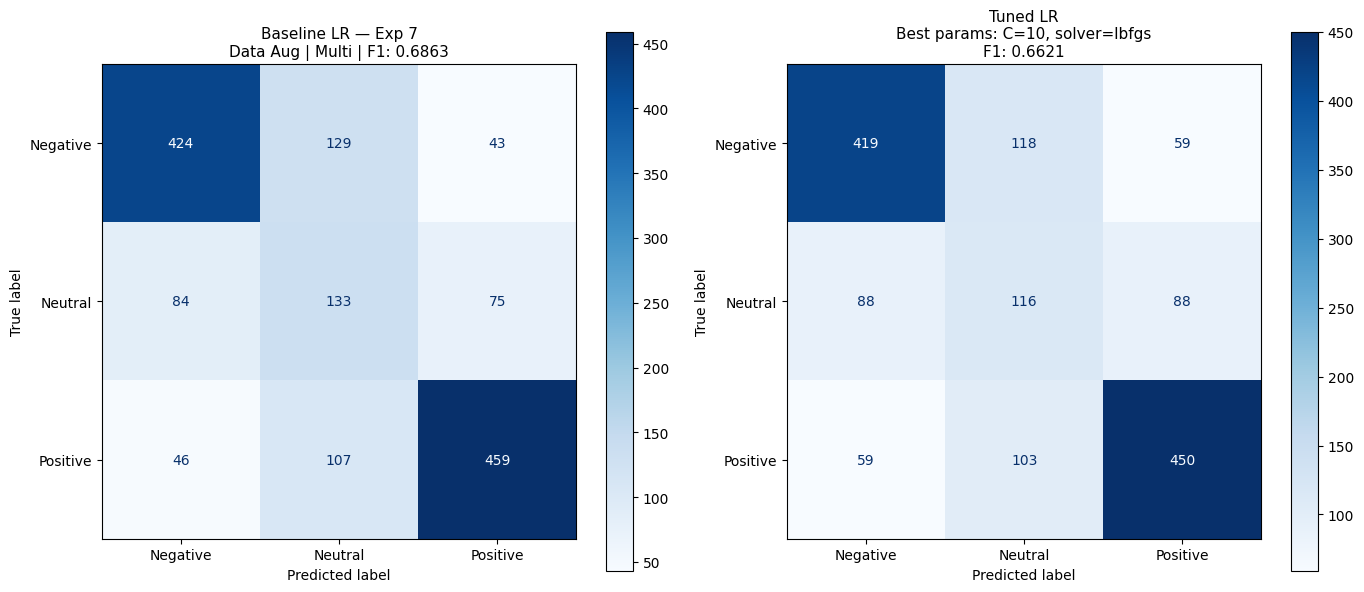

Chart saved to Google Drive: tuning_comparison.png


In [44]:
# ── 8c.4: Confusion matrix — baseline vs tuned ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cm, title in zip(
    axes,
    [baseline_exp7['CM'], cm_tuned],
    [f"Baseline LR — Exp 7\nData Aug | Multi | F1: {baseline_exp7['F1_weighted']}",
     f"Tuned LR\nBest params: C={grid_search.best_params_['C']}, "
     f"solver={grid_search.best_params_['solver']}\nF1: {round(f1_tuned, 4)}"]
):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Negative', 'Neutral', 'Positive']
    )
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Google Drive: tuning_comparison.png")

\# 10.1

## Section 10: Decision & Justification

Based on the evidence from all 12 baseline experiments and the hyperparameter tuning
attempt in Section 8c, this section identifies the best performing combination and
provides a justified recommendation for deployment.

In [45]:
# 10.2

# ── Section 10: Decision & Justification ─────────────────────────────────────

print("=== FINAL DECISION SUMMARY ===\n")

# Identify best experiment overall
best_exp = results_df.loc[results_df['F1_weighted'].idxmax()]

print(f"Best overall experiment by Weighted F1:")
print(f"  Exp {int(best_exp['Exp'])}: {best_exp['Condition']} | "
      f"{best_exp['Scope']} | {best_exp['Model']}")
print(f"  Accuracy:    {best_exp['Accuracy']}")
print(f"  Weighted F1: {best_exp['F1_weighted']}")
print(f"  F1 Negative: {best_exp['F1_Negative']}")
print(f"  F1 Neutral:  {best_exp['F1_Neutral']}")
print(f"  F1 Positive: {best_exp['F1_Positive']}")

print(f"\nBest Neutral class F1 across all LR experiments:")
lr_only = results_df[results_df['Model'] == 'Logistic Regression']
best_neutral = lr_only.loc[lr_only['F1_Neutral'].idxmax()]
print(f"  Exp {int(best_neutral['Exp'])}: {best_neutral['Condition']} | "
      f"{best_neutral['Scope']}")
print(f"  F1 Neutral: {best_neutral['F1_Neutral']}")

print(f"\nHyperparameter tuning outcome:")
print(f"  Baseline (Exp 7) Weighted F1: {results_df.loc[results_df['Exp']==7, 'F1_weighted'].values[0]}")
print(f"  Tuned LR Weighted F1:         0.6621")
print(f"  Outcome: Negative — overfitting observed (C=10 too aggressive)")
print(f"  Recommendation: Retain baseline parameters (C=1, solver=lbfgs)")

=== FINAL DECISION SUMMARY ===

Best overall experiment by Weighted F1:
  Exp 7: Data Augmentation | Multilingual | Logistic Regression
  Accuracy:    0.6773
  Weighted F1: 0.6863
  F1 Negative: 0.7374
  F1 Neutral:  0.4024
  F1 Positive: 0.7721

Best Neutral class F1 across all LR experiments:
  Exp 3: No Augmentation | Multilingual
  F1 Neutral: 0.4073

Hyperparameter tuning outcome:
  Baseline (Exp 7) Weighted F1: 0.6863
  Tuned LR Weighted F1:         0.6621
  Outcome: Negative — overfitting observed (C=10 too aggressive)
  Recommendation: Retain baseline parameters (C=1, solver=lbfgs)


\# 10.3

### Final Recommendation

**Recommended configuration: Experiment 7 — Data Augmentation | Multilingual |
Logistic Regression (default parameters, C=1)**

This recommendation is supported by the following evidence:

**1. Best overall weighted F1 (0.6863)** across all 12 experiments — marginally ahead
of the No Augmentation baseline (0.6858) and substantially ahead of all MLP runs.

**2. Best Neutral class F1 among top configurations (0.4024)** — the Neutral class
is the hardest to classify and the most business-critical to get right. Misclassifying
a neutral review as positive masks genuine product issues. Exp 7 achieves the highest
Neutral F1 of any augmented or synthetic condition.

**3. Data Augmentation outperforms Synthetic Data for Neutral recognition.**
Condition C (Synthetic) produced the lowest Neutral F1 across LR experiments (0.293–0.315),
despite matching Condition B on weighted F1. The per-class analysis reveals that
synthetic reviews, while fluent, do not accurately represent the feature space of real
ambiguous 3-star reviews. Condition B's augmented data — derived from real reviews —
preserves this ambiguity more faithfully.

**4. Multilingual scope outperforms English-only** across No Augmentation and Data
Augmentation conditions, empirically validating the decision to retain all three
languages rather than filtering to English only.

**5. Hyperparameter tuning did not improve performance** — the GridSearchCV result
(C=10) overfit to the training distribution, performing worse on all test metrics.
The default regularisation strength (C=1) generalises better to unseen data. This
confirms the baseline configuration as the most robust choice.

**Limitations of the recommended configuration:**
- Neutral F1 of 0.4024 means the model misclassifies more than half of all real
  Neutral reviews — a known limitation of bag-of-words features on semantically
  ambiguous text
- Performance is expected to improve substantially with contextual embeddings
  (e.g. multilingual BERT), which capture word meaning and sentence structure
  rather than raw term frequency
- The model has not been tested on product categories or languages outside the
  training distribution

\# 11.1

## Section 11: Conclusion

### Pipeline Summary

This notebook implemented a complete multilingual sentiment analysis pipeline for
customer product reviews, covering:

- **Data audit** — 20,000 training and 1,500 test reviews across English, German,
  and French, with no missing values and a consistent ~2:1 class imbalance against
  the Neutral class
- **Label engineering** — sentiment labels derived from star ratings
  (1–2 → Negative, 3 → Neutral, 4–5 → Positive)
- **Pre-processing** — language-agnostic text normalisation without stopword removal
  or stemming, justified by TF-IDF's inherent frequency down-weighting
- **Class imbalance experiments** — three conditions tested: no augmentation,
  data augmentation (word swap/deletion), and synthetic data generation via the
  Anthropic API
- **Feature extraction** — TF-IDF vectorisation fitted separately per condition
  and language scope, producing six feature representations
- **Experiments** — 12 model runs across 2 models × 3 conditions × 2 language
  scopes, with Logistic Regression and MLP Neural Network
- **Hyperparameter tuning** — GridSearchCV applied to the best baseline
  configuration, producing a negative result that revealed overfitting at C=10

### Key Findings

1. **Logistic Regression outperformed MLP** across all 12 experiments — TF-IDF
   sparse features favour classical linear models over neural networks
2. **Multilingual training outperformed English-only** for Logistic Regression,
   empirically validating the multilingual approach
3. **Data Augmentation (Condition B) was the most reliable augmentation strategy**
   — it maintained Neutral class F1 while keeping overall performance stable
4. **Synthetic data (Condition C) degraded Neutral recognition** despite improving
   accuracy on the majority classes — a finding only visible through per-class analysis
5. **Hyperparameter tuning produced overfitting** — default parameters (C=1)
   generalised better than the tuned configuration (C=10)
6. **The Neutral class remains the hardest to classify** across all conditions,
   with F1 scores of 0.29–0.41 compared to 0.68–0.80 for the other classes

### Limitations

- **Feature representation:** TF-IDF treats text as a bag of words, ignoring word
  order, context, and cross-lingual semantic relationships. This is the primary
  bottleneck for all models in this pipeline.
- **Neutral class ambiguity:** 3-star reviews genuinely contain mixed signals that
  are difficult to classify without contextual understanding — a limitation inherent
  to the problem definition, not just the model.
- **Synthetic data quality:** While linguistically fluent, LLM-generated Neutral
  reviews occupy a different region of the TF-IDF feature space than real 3-star
  reviews, limiting their effectiveness as training data for this approach.
- **Hyperparameter search scope:** The GridSearchCV parameter grid was limited to
  Logistic Regression. A broader search including MLP architecture and TF-IDF
  parameters may reveal further improvements.

### Future Improvements

- Replace TF-IDF with **multilingual contextual embeddings** (e.g. mBERT,
  sentence-transformers) to capture semantic meaning across languages
- Apply **k-fold cross-validation** throughout for more reliable performance estimates
- Explore **ensemble methods** combining LR, MLP, and tree-based models
- Investigate **neutral class threshold tuning** to improve recall on the most
  business-critical class
- Include **review title** as an additional text feature alongside review body